In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de Seaborn para mejorar la visualización
sns.set(style="whitegrid")

In [2]:
# Cargamos los datos desde los archivos CSV
data1 = pd.read_csv('../data/raw/airline_satisfaction_part1.csv')
data2 = pd.read_csv('../data/raw/airline_satisfaction_part2.csv')

# Combinamos los dos DataFrames en uno solo
data = pd.concat([data1, data2], ignore_index=True)

In [3]:
# Mostramos las primeras filas del DataFrame combinado para tener una vista preliminar de los datos
print(data.head())

# Obtenemos información general del DataFrame, incluyendo el tipo de datos y la cantidad de valores no nulos por columna
print(data.info())

# Calculamos estadísticas descriptivas para las columnas numéricas
print(data.describe())

   Unnamed: 0     id  Gender      Customer Type  Age   Type of Travel  \
0           0  19556  Female     Loyal Customer   52  Business travel   
1           1  90035  Female     Loyal Customer   36  Business travel   
2           2  12360    Male  disloyal Customer   20  Business travel   
3           3  77959    Male     Loyal Customer   44  Business travel   
4           4  36875  Female     Loyal Customer   49  Business travel   

      Class  Flight Distance  Inflight wifi service  \
0       Eco              160                      5   
1  Business             2863                      1   
2       Eco              192                      2   
3  Business             3377                      0   
4       Eco             1182                      2   

   Departure/Arrival time convenient  ...  Inflight entertainment  \
0                                  4  ...                       5   
1                                  1  ...                       4   
2                      

In [4]:
# Contamos la cantidad de valores nulos/faltantes en cada columna
data.isnull().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction    

In [5]:
# Rellenamos los valores faltantes en una columna específica con la mediana de la columna
data['Arrival Delay in Minutes'].fillna(data['Arrival Delay in Minutes'].median(), inplace=True)

# Contamos nuevamente la cantidad de valores nulos/faltantes en cada columna
data.isnull().sum()

Unnamed: 0                           0
id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

In [6]:
# Contamos la cantidad de filas duplicadas
print(data.duplicated().sum())

0


In [7]:
# Convertimos columnas a los tipos de datos correctos
data["Arrival Delay in Minutes"] = data["Arrival Delay in Minutes"].astype("int")

print(data.dtypes)

Unnamed: 0                            int64
id                                    int64
Gender                               object
Customer Type                        object
Age                                   int64
Type of Travel                       object
Class                                object
Flight Distance                       int64
Inflight wifi service                 int64
Departure/Arrival time convenient     int64
Ease of Online booking                int64
Gate location                         int64
Food and drink                        int64
Online boarding                       int64
Seat comfort                          int64
Inflight entertainment                int64
On-board service                      int64
Leg room service                      int64
Baggage handling                      int64
Checkin service                       int64
Inflight service                      int64
Cleanliness                           int64
Departure Delay in Minutes      

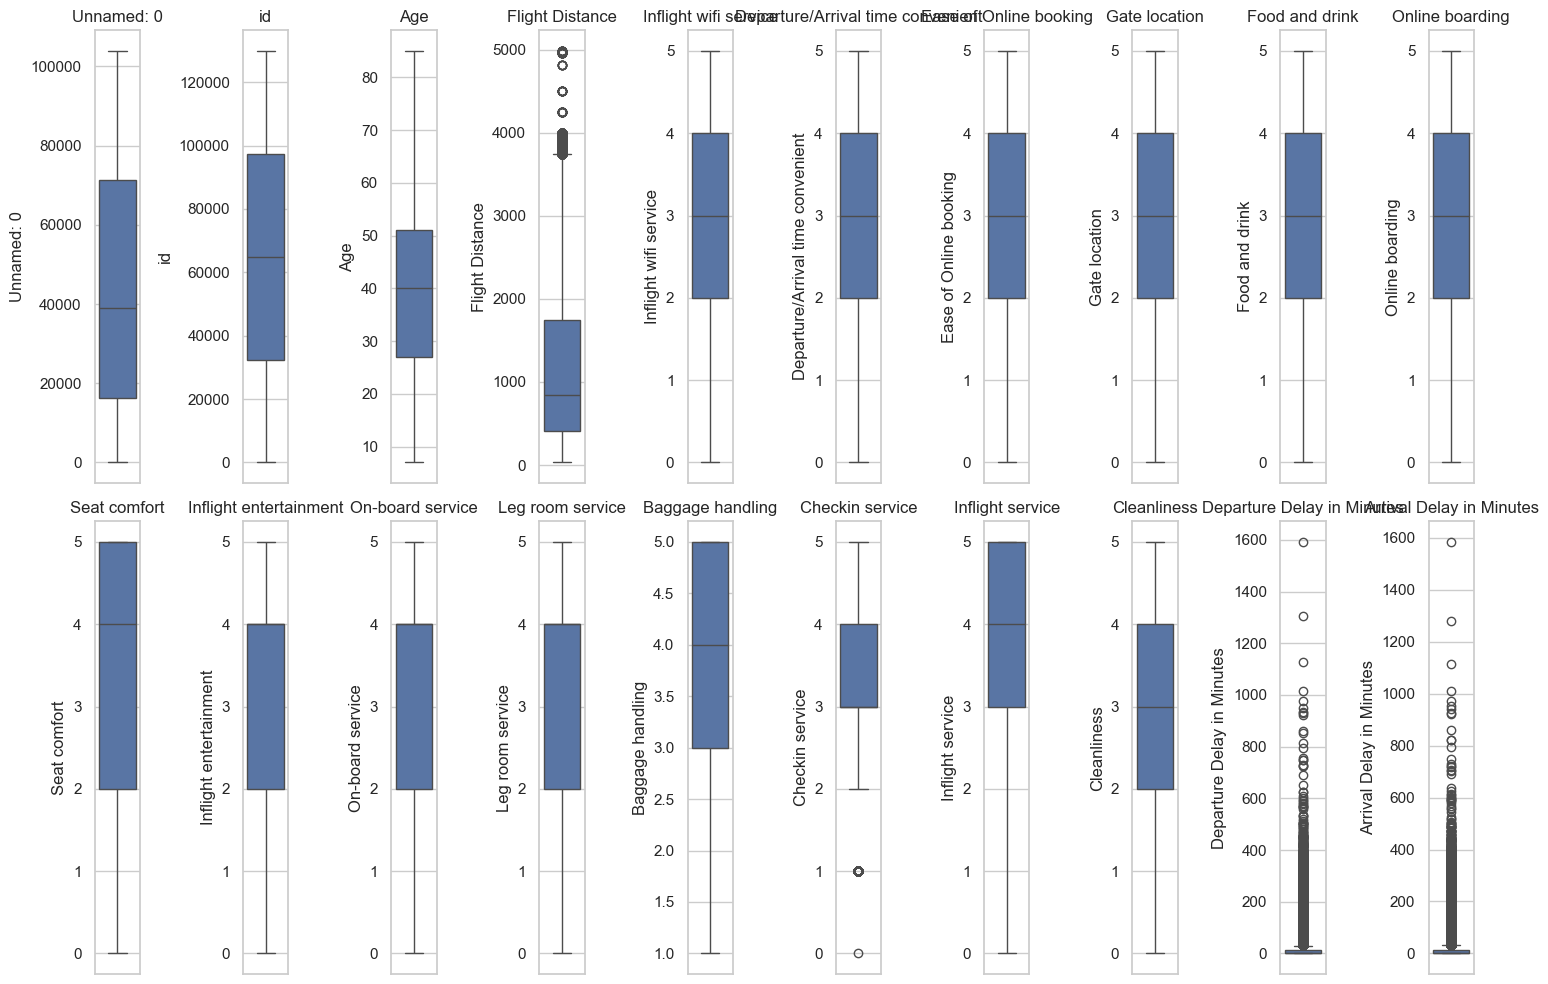

In [8]:
# Seleccionamos las columnas numéricas para visualización
num_columns = data.select_dtypes(include=[np.number]).columns

# Creamos subplots de boxplots para cada columna numérica
plt.figure(figsize=(15, 10))  # Ajustamos el tamaño de la figura

# Crear un boxplot para cada columna numérica
for i, column in enumerate(num_columns, 1):
    plt.subplot(2, (len(num_columns) + 1) // 2, i) # Ajustamos la cuadrícula para tener suficiente espacio
    sns.boxplot(y=data[column])
    plt.title(column)

plt.tight_layout() # Ajustamos el layout para evitar superposiciones
plt.show()


<Axes: >

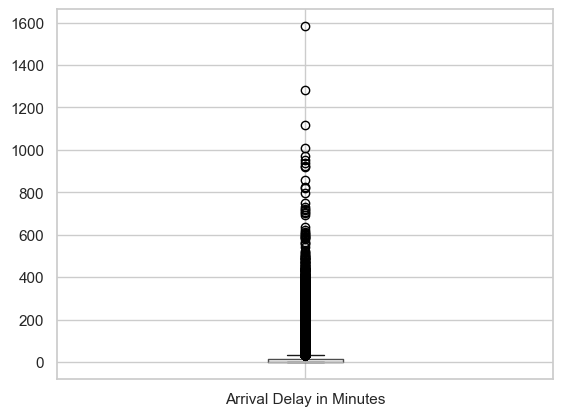

In [9]:
# Destacamos valores atípicos en la columna "Arrival Delay in Minutes"
data.boxplot(["Arrival Delay in Minutes"])

In [10]:
# Identificamos y manejamos valores atípicos en la columna 'Arrival Delay in Minutes' usando el método IQR
Q1 = data["Arrival Delay in Minutes"].quantile(.25)
Q3 = data["Arrival Delay in Minutes"].quantile(.75)

IQR = Q3 - Q1

# Definimos límites para identificar valores atípicos
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtramos los datos para eliminar los valores atípicos
data = data[(data["Arrival Delay in Minutes"] >= lower_bound) & (data["Arrival Delay in Minutes"] <= upper_bound)]

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112388 entries, 1 to 129879
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   Unnamed: 0                         112388 non-null  int64 
 1   id                                 112388 non-null  int64 
 2   Gender                             112388 non-null  object
 3   Customer Type                      112388 non-null  object
 4   Age                                112388 non-null  int64 
 5   Type of Travel                     112388 non-null  object
 6   Class                              112388 non-null  object
 7   Flight Distance                    112388 non-null  int64 
 8   Inflight wifi service              112388 non-null  int64 
 9   Departure/Arrival time convenient  112388 non-null  int64 
 10  Ease of Online booking             112388 non-null  int64 
 11  Gate location                      112388 non-null  int64

<Axes: >

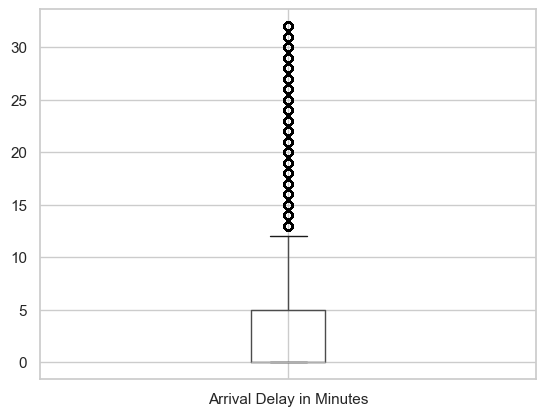

In [11]:
# Confirmamos visualmente la eliminación de valores atípicos con un boxplot
data.boxplot(["Arrival Delay in Minutes"])

In [12]:
# Guardamos el DataFrame limpio en un archivo CSV en la carpeta 'processed'
data.to_csv("../data/processed/airline_satisfaction_cleaned.csv", index=False)